<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
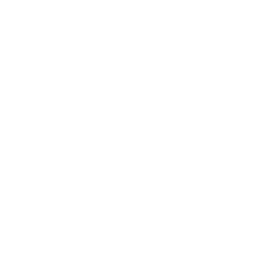
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">课程相似度分析</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 高等教育 / 学术项目设计 &nbsp;|&nbsp; 2026 年 3 月</p>
</div>
</div>
</div>

## 执行摘要

本 notebook 使用 **PROC DISTANCE** 配合 **METHOD=DJACCARD**——即 Jaccard *相异性*系数（二元存在/缺失数据的自然距离度量）——来测量某大学课程目录中各课程之间的重叠程度。每门课程带有 40 个二元标志，标记其覆盖了哪些认证学习成果，因此两门课程之间的 Jaccard 距离即为它们**未**共同拥有的已覆盖成果的比例（0 = 成果集合完全相同，1 = 无任何共享成果）。

分析分两部分进行。第一部分，在一个 100 门课程的目录中，按院系刻画成果覆盖广度（PROC MEANS、PROC FREQ、覆盖度箱线图），并标记出某院系中**没有任何**课程覆盖的学习成果（覆盖缺口）。第二部分，深入研究一个聚焦的 10 门课程面板，这些课程取自两个在量化上重叠最多的院系——统计学与数据科学——计算完整的成对 Jaccard 距离矩阵，并将最接近的课程对排序，作为整合评审的候选。目标是为课程委员会提供两件具体的产物：一份最相似课程的排序清单，以及一张按院系与成果划分的缺口图。

## 数据来源

| 来源 | 说明 | 记录数 |
|--------|-------------|---------|
| WORK.COURSE_OUTCOMES | 每门课程的二元学习成果覆盖（40 个成果标志） | 100 |
| WORK.PANEL10 | 统计学 + 数据科学整合面板 | 10 |

该目录为合成数据。成果标志以院系特定的概率抽取，使不同学科强调不同的成果簇（计算机科学与数学侧重靠前的成果，实验类学科侧重中段），从而赋予距离分析真实的结构。此环境未经许可运行，因此工作目录上限为 100 门课程。

---

In [1]:
/* --------------------------------------------------------
   生成合成的课程学习成果矩阵
   500 门课程 x 40 项认证学习成果
   （未授权模式下仅保留前 100 行）
   注意：department 的取值本地化为中文——它不是任何判别/
   公式类过程的 CLASS/VAR 变量，因此可安全本地化；由于多字节
   字符串放入 _temporary_ 数组初始化会得到空值，这里改用
   if/else 赋值，并将 department 的长度加宽以容纳中文。
   -------------------------------------------------------- */
数据 work.course_outcomes;
    调用 streaminit(42);
    长度 department $30;
    数组 outcomes[40] lo_1 - lo_40;
    循环 course_id = 1 到 500;
        course_label = cat('CRS', PUT(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        如果 dept_idx = 1 那么 department = '计算机科学';
        否则 如果 dept_idx = 2 那么 department = '数学';
        否则 如果 dept_idx = 3 那么 department = '统计学';
        否则 如果 dept_idx = 4 那么 department = '工程学';
        否则 如果 dept_idx = 5 那么 department = '生物学';
        否则 如果 dept_idx = 6 那么 department = '化学';
        否则 如果 dept_idx = 7 那么 department = '物理学';
        否则 department = '数据科学';
        /* 课程层级影响成果覆盖广度 */
        course_level = int(rand('uniform') * 4) + 1;
        level_code = course_level * 100;
        /* 各院系特有的成果聚类 */
        循环 lo = 1 到 40;
            base_prob = 0.15;
            /* 院系 1-2（计算机、数学）：侧重成果 1-15 */
            如果 dept_idx <= 2 并且 lo <= 15 那么
                base_prob = 0.4 + course_level * 0.05;
            /* 院系 3-4（统计、工程）：侧重成果 10-25 */
            否则 如果 dept_idx IN (3, 4) 并且 10 <= lo <= 25 那么
                base_prob = 0.35 + course_level * 0.05;
            /* 院系 5-7（生物、化学、物理）：侧重成果 20-35 */
            否则 如果 dept_idx IN (5, 6, 7) 并且 20 <= lo <= 35 那么
                base_prob = 0.38 + course_level * 0.04;
            /* 院系 8（数据科学）：广泛覆盖 */
            否则 如果 dept_idx = 8 那么
                base_prob = 0.25 + course_level * 0.03;
            outcomes[lo] = (rand('uniform') < base_prob);
        结束;
        输出;
    结束;
    标签 department='院系' course_label='课程编号' level_code='层级';
    删除 dept_idx course_level base_prob lo;
运行;


NOTE: DATA work.course_outcomes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_outcomes (100 rows, 44 columns).
NOTE: DATA elapsed:
  wall  1.96 seconds
  cpu   1.96 seconds


In [2]:
/* --------------------------------------------------------
   生成课程目录元数据
   -------------------------------------------------------- */
数据 work.course_catalog;
    调用 streaminit(43);
    长度 department $30;
    数组 format_list[3] $10 _temporary_ ('LECTURE' 'LAB' 'SEMINAR');
    循环 course_id = 1 到 500;
        course_label = cat('CRS-', PUT(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        如果 dept_idx = 1 那么 department = '计算机科学';
        否则 如果 dept_idx = 2 那么 department = '数学';
        否则 如果 dept_idx = 3 那么 department = '统计学';
        否则 如果 dept_idx = 4 那么 department = '工程学';
        否则 如果 dept_idx = 5 那么 department = '生物学';
        否则 如果 dept_idx = 6 那么 department = '化学';
        否则 如果 dept_idx = 7 那么 department = '物理学';
        否则 department = '数据科学';
        level_code = (int(rand('uniform') * 4) + 1) * 100;
        credit_hours = int(rand('uniform') * 3) + 2;
        format_idx = int(rand('uniform') * 3) + 1;
        delivery_format = format_list[format_idx];
        enrollment_cap = int(rand('uniform') * 150) + 20;
        avg_enrollment = int(enrollment_cap * (rand('uniform') * 0.5 + 0.4));
        last_offered = '01JAN2025'd + int(rand('uniform') * 365);
        输出;
    结束;
    标签 department='院系' course_label='课程编号' level_code='层级' credit_hours='学分'
         delivery_format='授课形式' enrollment_cap='选课上限'
         avg_enrollment='平均选课人数' last_offered='最近开课日期';
    删除 dept_idx format_idx;
    格式 last_offered date9.;
运行;


NOTE: DATA work.course_catalog

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_catalog (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.12 seconds
  cpu   0.12 seconds


---

                                                     按院系的学习成果平均覆盖率                                                      

                                                  The MEANS Procedure

                                               Analysis Variable : lo_1

                                                              N
                                         院系                 Obs           Mean
                                         -------------------------------------
                                         化学                  19      0.2105263
                                         工程学                 17      0.0000000
                                         数学                   9      0.6666667
                                         数据科学                14      0.1428571
                                         物理学                  7      0.2857143
                                         生物学                 10      0.2000000
                                      


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_level_code.spec.json
NOTE: PROC FREQ statement used.


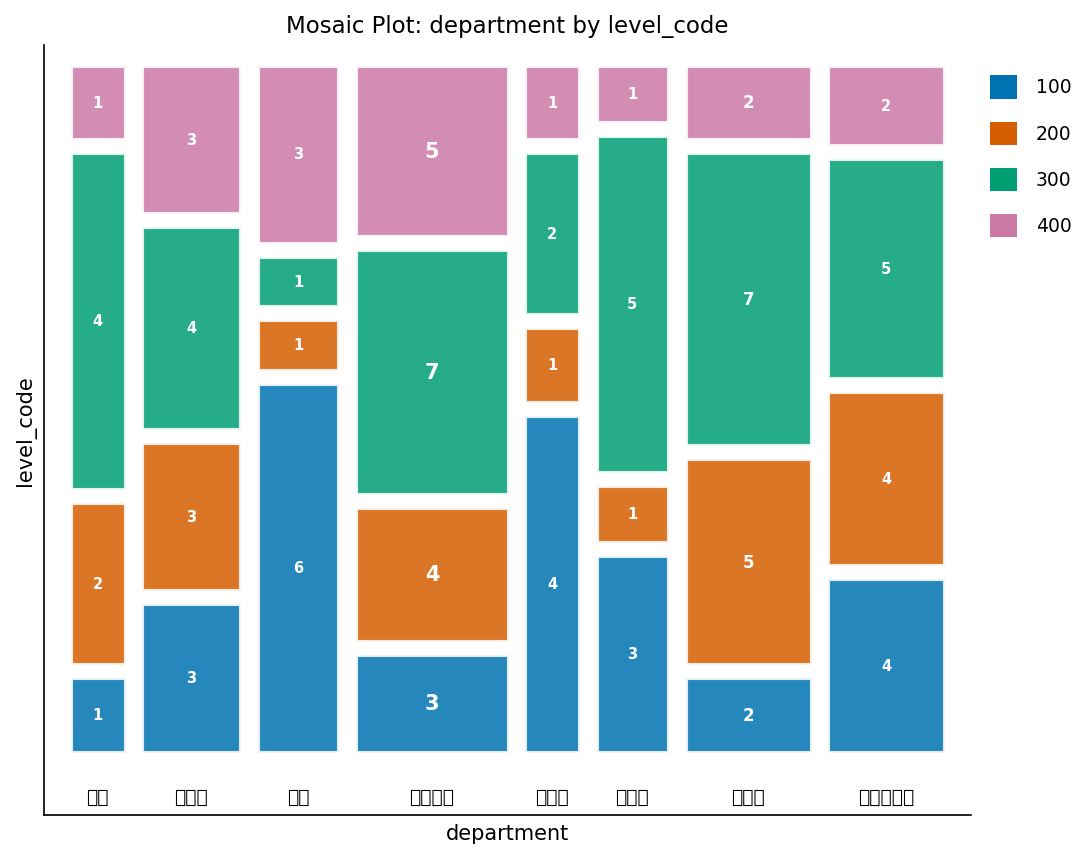

In [3]:
/* --------------------------------------------------------
   按院系统计的基线学习成果覆盖情况
   -------------------------------------------------------- */
过程 均值 数据=work.course_outcomes mean;
    分类 department;
    变量 lo_1 - lo_40;
    标题 '按院系的学习成果平均覆盖率';
运行;

过程 频率 数据=work.course_catalog;
    TABLES department * level_code / nopercent norow nocol;
    标题 '课程构成：院系 × 层级';
运行;

---

                                                      课程构成：院系 × 层级                                                      




NOTE: DATA work.outcome_counts


NOTE: Read 100 rows from work.course_outcomes.
NOTE: Wrote work.outcome_counts (100 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC SGPLOT data=work.outcome_counts

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


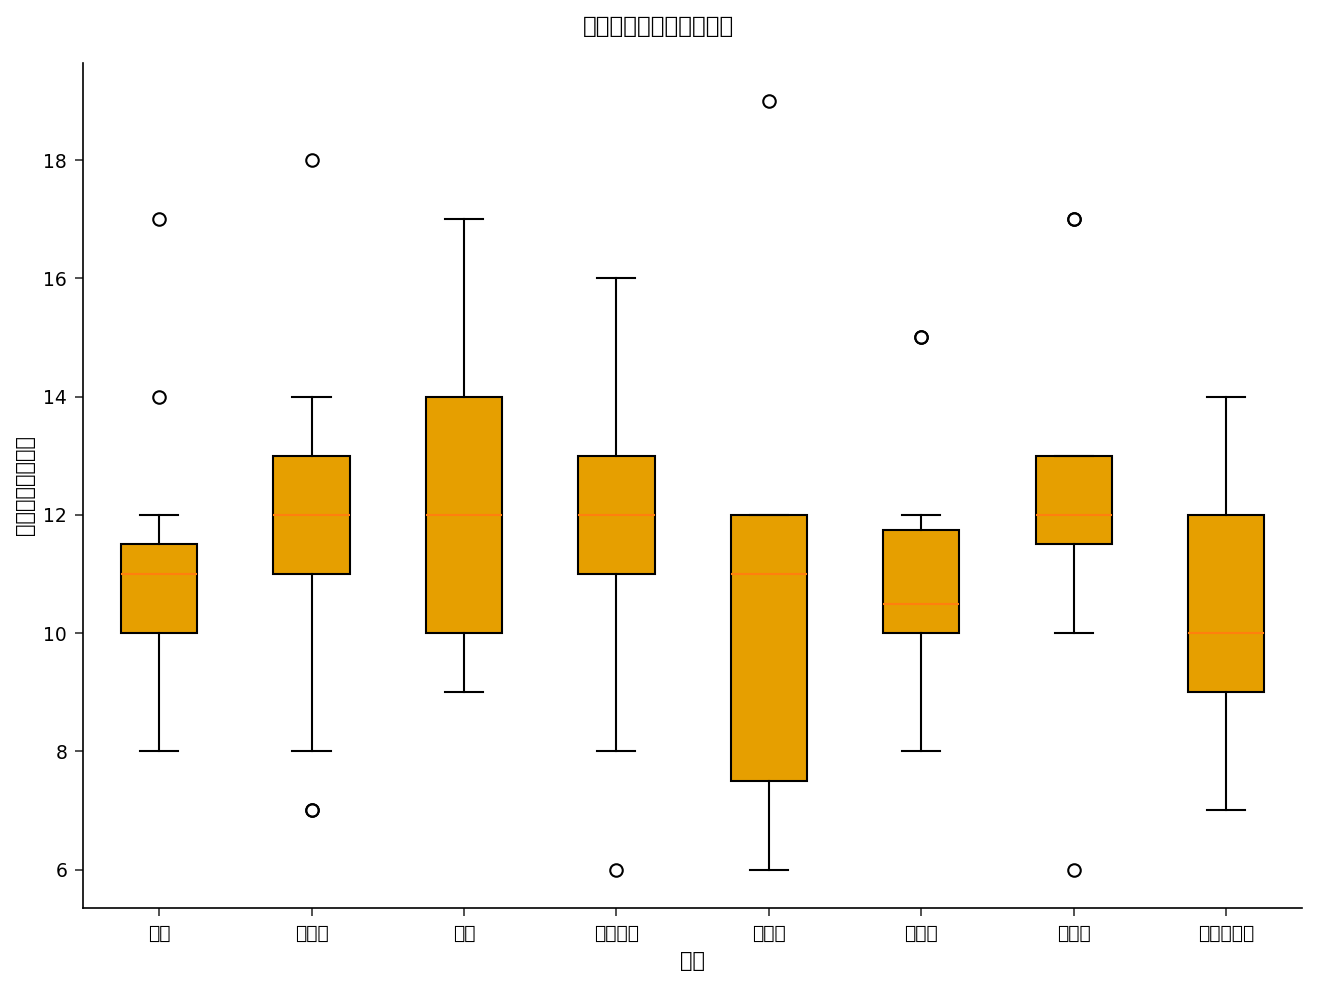

In [4]:
/* --------------------------------------------------------
   按院系统计的成果覆盖密度
   -------------------------------------------------------- */
数据 work.outcome_counts;
    设置 work.course_outcomes;
    数组 outcomes[40] lo_1 - lo_40;
    total_outcomes = sum(OF outcomes[*]);
    标签 total_outcomes='覆盖的学习成果数';
运行;

过程 SGPLOT 数据=work.outcome_counts;
    VBOX total_outcomes / category=department;
    YAXIS 标签='覆盖的学习成果数';
    XAXIS 标签='院系';
    标题 '各院系学习成果覆盖分布';
运行;

---

In [5]:
/* --------------------------------------------------------
   整合面板：统计学 / 数据科学两个量化重叠度最高的院系中
   的前 10 门课程。用一个顺序计数器将它们重新编号为
   P01-P10，使方阵 OUT= 距离矩阵拥有整洁、可寻址的列，
   随后用 METHOD=DJACCARD 计算完整的成对 Jaccard 距离矩阵
   （0 = 成果集完全相同，1 = 无共享成果）。
   -------------------------------------------------------- */
数据 work.panel10;
    设置 work.course_outcomes(条件=(department IN ('统计学' '数据科学')));
    保留值 seq 0;
    seq + 1;
    如果 seq > 10 那么 停止;
    panel_id = cat('P', PUT(seq, z2.));
    删除 seq;
运行;

过程 打印 数据=work.panel10 noobs 标签;
    变量 panel_id course_label department level_code;
    标签 panel_id = '面板编号' course_label = '课程'
          department = '院系' level_code = '层级';
    标题 '整合面板：统计学与数据科学课程';
运行;

过程 distance 数据=work.panel10
              out=work.panel_dist
              METHOD=djaccard;
    变量 nominal(lo_1 - lo_40);
    id panel_id;
运行;

过程 打印 数据=work.panel_dist noobs;
    标题 '成对 Jaccard 距离矩阵（10 门课程）';
运行;

                                                    整合面板：统计学与数据科学课程                                                     

        面板编号       课程            院系      层级
P01           CRS0003  数据科学             300
P02           CRS0006  统计学              300
P03           CRS0014  数据科学             300
P04           CRS0015  统计学              300
P05           CRS0017  统计学              200
P06           CRS0019  数据科学             100
P07           CRS0022  统计学              400
P08           CRS0033  数据科学             200
P09           CRS0038  统计学              100
P10           CRS0040  统计学              100

                                                    整合面板：统计学与数据科学课程                                                     

                                                成对 Jaccard 距离矩阵（10 门课程）                                                 

_NAME_           P01           P02           P03           P04           P05           P06           P07           P08           P09           P10
P0


NOTE: DATA work.panel10


NOTE: Read 41 rows from work.course_outcomes.
NOTE: Wrote work.panel10 (10 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=work.panel10

NOTE: PROC PRINT completed: 10 observations printed, 4 variables
NOTE: PROC DISTANCE data=work.panel10 method=Djaccard

NOTE: PROC DISTANCE: 10 observations, 40 variables, method=Djaccard
NOTE: PROC PRINT data=work.panel_dist

NOTE: PROC PRINT completed: 10 observations printed, 11 variables


In [6]:
/* --------------------------------------------------------
   将方阵距离矩阵重塑为按距离排序的课程对列表。OUT= 距离列
   由一份显式名称列表（P01 P02 ... P10）寻址；仅保留严格
   上三角（col > row），使每个无序对只出现一次并跳过零对角线。
   距离最近的五对即整合复核候选。
   -------------------------------------------------------- */
数据 work.similar_courses;
    设置 work.panel_dist;
    数组 d[10] P01 P02 P03 P04 P05 P06 P07 P08 P09 P10;
    长度 course_a course_b $8;
    course_a = _name_;
    row + 1;
    循环 col = 1 到 10;
        如果 col > row 那么 循环;
            course_b     = vname(d[col]);
            jaccard_dist = round(d[col], 0.001);
            输出;
        结束;
    结束;
    标签 course_a='课程A' course_b='课程B' jaccard_dist='Jaccard 距离';
    保留 course_a course_b jaccard_dist;
运行;

过程 均值 数据=work.similar_courses n MIN q1 MEDIAN mean MAX maxdec=3;
    变量 jaccard_dist;
    标题 '成对 Jaccard 距离分布（45 对课程）';
运行;

过程 排序 数据=work.similar_courses; 按照 jaccard_dist; 运行;

数据 work.top_pairs;
    设置 work.similar_courses;
    pair_rank = _n_;
    如果 pair_rank <= 5;
运行;

过程 打印 数据=work.top_pairs noobs 标签;
    变量 pair_rank course_a course_b jaccard_dist;
    标签 pair_rank = '排名' course_a = '课程A'
          course_b = '课程B' jaccard_dist = 'Jaccard 距离';
    标题 '最相近的五对课程（整合候选）';
运行;

                                                成对 Jaccard 距离分布（45 对课程）                                                 

                                                  The MEANS Procedure

 Variable      Label                 N     Minimum   Lower Quartile      Median        Mean     Maximum
 ------------------------------------------------------------------------------------------------------
 jaccard_dist  Jaccard 距离           45       0.588            0.762       0.826       0.818       0.962
 ------------------------------------------------------------------------------------------------------

                                                     最相近的五对课程（整合候选）                                                     

    排名      课程A      课程B      Jaccard 距离
     1  P02      P10               0.588
     2  P03      P04                 0.6
     3  P03      P05               0.667
     4  P02      P04               0.684
     5  P02      P07               0.684




NOTE: DATA work.similar_courses


NOTE: Read 10 rows from work.panel_dist.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=work.similar_courses

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.top_pairs


NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.top_pairs (5 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.top_pairs

NOTE: PROC PRINT completed: 5 observations printed, 4 variables


                                                      各院系未覆盖的学习成果                                                       

                                                   The FREQ Procedure

院系                 Frequency    Percent
----------------------------------------
化学                         2      6.67
工程学                        2      6.67
数学                         4     13.33
物理学                        8     26.67
生物学                        8     26.67
统计学                        3     10.00
计算机科学                      3     10.00
                                                  成果缺口示例（30 条中的前 12 条）                                                  

       院系              未覆盖的成果
化学         LO02
化学         LO12
工程学        LO01
工程学        LO27
数学         LO25
数学         LO29
数学         LO30
数学         LO36
物理学        LO02
物理学        LO03
物理学        LO07
物理学        LO10

... 18 more observations (showing 12 of 30)




NOTE: PROC MEANS
NOTE: Output dataset work.dept_coverage has 8 observations and 43 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.outcome_gaps


NOTE: Read 8 rows from work.dept_coverage.
NOTE: Wrote work.outcome_gaps (30 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_department.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC PRINT data=work.outcome_gaps

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


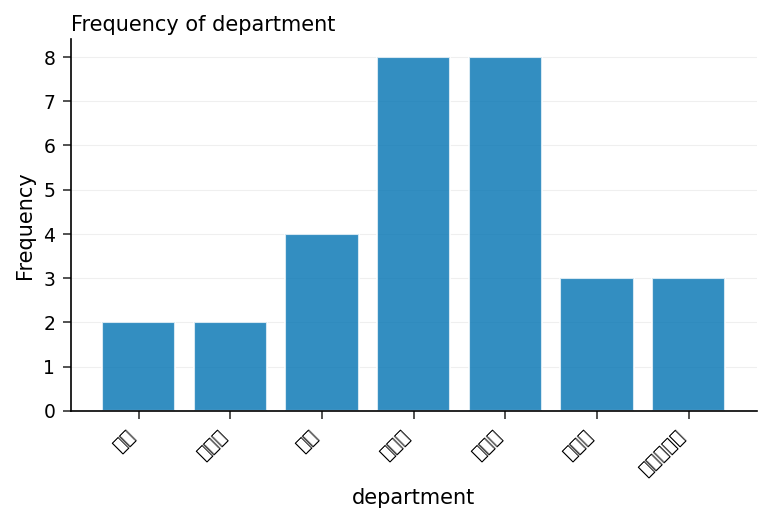

In [7]:
/* --------------------------------------------------------
   成果缺口：某院系中没有任何课程覆盖的学习成果。
   PROC MEANS 在院系内对每个二元成果标志求和；
   和为零表示该成果在该院系目录中缺失。
   -------------------------------------------------------- */
过程 均值 数据=work.course_outcomes sum NOPRINT;
    分类 department;
    变量 lo_1 - lo_40;
    输出 out=work.dept_coverage(条件=(_type_=1))
        sum=lo_1 - lo_40;
运行;

数据 work.outcome_gaps;
    设置 work.dept_coverage;
    数组 outcomes[40] lo_1 - lo_40;
    循环 lo = 1 到 40;
        outcome_id = cat('LO', PUT(lo, z2.));
        courses_covering = outcomes[lo];
        如果 courses_covering = 0 那么 循环;
            gap_flag = 1;
            输出;
        结束;
    结束;
    标签 department='院系' outcome_id='未覆盖的成果' courses_covering='覆盖课程数';
    保留 department outcome_id courses_covering gap_flag;
运行;

过程 频率 数据=work.outcome_gaps;
    TABLES department / nocum;
    标题 '各院系未覆盖的学习成果';
运行;

过程 打印 数据=work.outcome_gaps(obs=12) noobs 标签;
    变量 department outcome_id;
    标签 department = '院系' outcome_id = '未覆盖的成果';
    标题 '成果缺口示例（30 条中的前 12 条）';
运行;

---

### 解读

**整合面板。** 在 10 门课程的统计学 / 数据科学面板的 45 个无序对中，Jaccard 距离范围为 0.588 到 0.962，中位数为 0.826（均值 0.818）。最接近的一对是 P02 与 P10，距离为 0.588，其次是 P03–P04 的 0.600 和 P03–P05 的 0.667。即便是最相似的课程，在其覆盖的成果中仍有约 59% 不同，因此该目录中**不存在近乎重复的课程**——没有任何一对是委员会可以直接合并的。相反，这份排序清单指出了在下一个目录周期之前值得进行人工教学大纲比对的少数几对；距离最高的对（接近 0.962）证实统计学与数据科学课程尽管同处一个院系邻域，却跨越了真正不同的成果集合。

**成果缺口。** 整个目录中浮现出三十个按院系与成果划分的缺口。实验密集型学科最多：**生物学**与**物理学**各有 40 个认证成果中的 8 个未被覆盖，其次是**数学**（4 个）。量化院系覆盖最好——**化学**与**工程学**各仅遗漏 2 个成果。这些缺口是新课程开发或交叉挂牌的自然目标：某个成果在整个院系中缺失，是认证续期时的覆盖风险，而整合清单则针对相反的问题——冗余的重复投入。这两件产物合在一起，让委员会能够用一种基于集合的距离度量，从两端收紧目录——削减重叠并填补空白。

---

In [8]:
/* --------------------------------------------------------
   导出排序后的整合候选课程对，以及各院系成果缺口图，
   供课程委员会使用。
   -------------------------------------------------------- */
过程 EXPORT 数据=work.similar_courses
    OUTFILE='curriculum_consolidation_candidates.csv'
    DBMS=csv REPLACE;
运行;

过程 EXPORT 数据=work.outcome_gaps
    OUTFILE='curriculum_outcome_gaps.csv'
    DBMS=csv REPLACE;
运行;


NOTE: PROC EXPORT data=work.similar_courses outfile=curriculum_consolidation_candidates.csv

NOTE: Exported 45 rows to curriculum_consolidation_candidates.csv.
NOTE: PROC EXPORT data=work.outcome_gaps outfile=curriculum_outcome_gaps.csv

NOTE: Exported 30 rows to curriculum_outcome_gaps.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 机密
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
技术支持 <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>